1.Import Libaries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler


2.Upload Dataset

In [2]:
train=pd.read_csv("Employee_attrition_train.csv")
val=pd.read_csv("Employee_attrition_validation.csv")
test=pd.read_csv("Employee_attrition_test.csv")
train


,employee_id,observation_date,tenure_months,role,department,shift,age_group,performance_score,attendance_rate_last_90days,late_arrivals_last_90days,overtime_hours_last_month,salary_percentile_in_role,promotions_received,lateral_moves,days_since_last_promotion,team_size,manager_tenure_months,training_hours_last_year,satisfaction_survey_score,attrition_flag
0,EMP-0001,2025-03-01,22.9,Dispatch Planner,Logistics Planning,Night,36-45,3,0.9345,3,19.7,81.6,0,2,835,24,105,56,4,1
1,EMP-0011,2025-03-01,25.1,Ground Handler,Fleet Management,Morning,36-45,3,0.9618,4,0.0,84.1,2,0,176,22,37,60,3,0
2,EMP-0039,2025-03-01,19.3,Cargo Agent,Quality & Compliance,Morning,36-45,3,0.9338,3,14.4,37.5,0,0,268,18,29,34,3,0
3,EMP-0049,2025-03-01,14.9,Quality Inspector,Ground Handling,Afternoon,36-45,1,1.0000,3,24.5,5.0,0,1,583,6,29,64,4,0
4,EMP-0064,2025-03-01,74.9,Dispatch Planner,Ground Handling,Night,26-35,3,0.9697,8,23.1,27.6,0,1,394,22,27,36,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,EMP-0229,2025-11-30,44.1,Cargo Agent,Ground Handling,Afternoon,56+,5,0.9078,5,24.5,64.1,0,0,843,17,13,48,3,0
6996,EMP-0232,2025-11-30,68.0,Warehouse Operator,Logistics Planning,Afternoon,36-45,5,1.0000,4,19.0,52.7,2,1,1179,20,9,41,4,0
6997,EMP-0238,2025-11-30,21.0,Cargo Agent,Cargo Operations,Afternoon,26-35,3,0.8963,2,26.6,28.2,1,3,982,20,59,46,2,0
6998,EMP-0249,2025-11-30,75.9,Ground Handler,Warehouse,Morning,46-55,3,0.9370,5,11.2,28.1,2,0,1105,17,17,44,2,1


3.Basic Checkups

In [3]:
print("Shape:", train.shape)
print("\nColumns:\n", train.columns)
print("\nData Types:\n", train.dtypes)


Shape: (7000, 20)

Columns:
 Index(['employee_id', 'observation_date', 'tenure_months', 'role',
       'department', 'shift', 'age_group', 'performance_score',
       'attendance_rate_last_90days', 'late_arrivals_last_90days',
       'overtime_hours_last_month', 'salary_percentile_in_role',
       'promotions_received', 'lateral_moves', 'days_since_last_promotion',
       'team_size', 'manager_tenure_months', 'training_hours_last_year',
       'satisfaction_survey_score', 'attrition_flag'],
      dtype='object')

Data Types:
 employee_id                     object
observation_date                object
tenure_months                  float64
role                            object
department                      object
shift                           object
age_group                       object
performance_score                int64
attendance_rate_last_90days    float64
late_arrivals_last_90days        int64
overtime_hours_last_month      float64
salary_percentile_in_role      float64


In [4]:
print("\nMissing Values:\n", train.isnull().sum())


Missing Values:
 employee_id                    0
observation_date               0
tenure_months                  0
role                           0
department                     0
shift                          0
age_group                      0
performance_score              0
attendance_rate_last_90days    0
late_arrivals_last_90days      0
overtime_hours_last_month      0
salary_percentile_in_role      0
promotions_received            0
lateral_moves                  0
days_since_last_promotion      0
team_size                      0
manager_tenure_months          0
training_hours_last_year       0
satisfaction_survey_score      0
attrition_flag                 0
dtype: int64


4.Data Understanding

In [5]:
#count of Employee
train['employee_id'].nunique()

250

In [6]:
# Count of unique employees per observation date
date_emp_count = (
    train.groupby('observation_date')['employee_id']
         .nunique()
         .reset_index(name='employee_count')
)
date_emp_count

,observation_date,employee_count
0,2025-03-01,28
1,2025-03-02,21
2,2025-03-03,32
3,2025-03-04,22
4,2025-03-05,26
...,...,...
270,2025-11-26,22
271,2025-11-27,30
272,2025-11-28,23
273,2025-11-29,25


In [7]:
#count of records per observation month
train['observation_date'] = pd.to_datetime(train['observation_date'])

monthly_counts = (
    train.assign(year_month=train['observation_date'].dt.to_period('M'))
      .groupby('year_month')
      .size()
      .reset_index(name='count')
)

monthly_counts

,year_month,count
0,2025-03,809
1,2025-04,793
2,2025-05,817
3,2025-06,754
4,2025-07,725
5,2025-08,820
6,2025-09,765
7,2025-10,793
8,2025-11,724


In [ ]:
emp_df = test[test['employee_id'] == 'EMP-0001']
emp_df

In [ ]:
emp_df = test[test['observation_date'] == '2026-01-01']
emp_df

* Dataset has around 250 unique employees and 275 observation dates, so data is collected multiple times (not one-time data).
* On each observation date, only 20–35 employees give survey, so data collection is not consistent or fixed.
* There is no proper pattern in survey collection, employees are not following any strict schedule to give responses.
* Same employee can give survey multiple times, and there is a gap between responses (example: after some days they respond again).
* Each employee has multiple records (approx. 18–25 times), so this is longitudinal/time-based data.
* For one employee (EMP0001), 18 responses are given (11 times = 1, 7 times = 0), so target value changes over time for same employee.
* This means attrition is not fixed per employee, it varies across different observation dates.


5. EDA Process


In [11]:
#separate numerical and categorical columns

num_cols = train.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('attrition_flag')
print("Numerical Columns:", num_cols)

cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols.remove('employee_id')
print("Categorical Columns:", cat_cols)


Numerical Columns: ['tenure_months', 'performance_score', 'attendance_rate_last_90days', 'late_arrivals_last_90days', 'overtime_hours_last_month', 'salary_percentile_in_role', 'promotions_received', 'lateral_moves', 'days_since_last_promotion', 'team_size', 'manager_tenure_months', 'training_hours_last_year', 'satisfaction_survey_score']
Categorical Columns: ['role', 'department', 'shift', 'age_group']


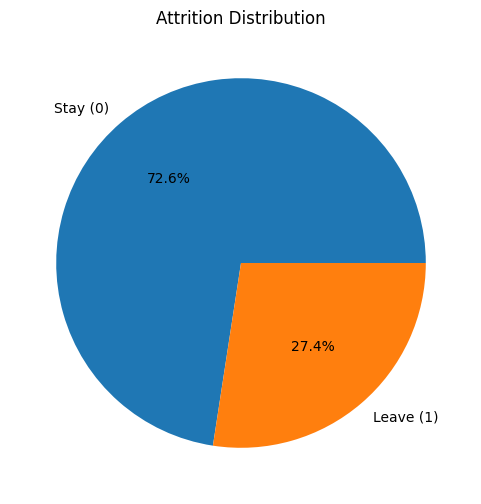

In [12]:
#pie chart for attrition distribution
attrition_counts = train['attrition_flag'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    attrition_counts,
    labels=['Stay (0)', 'Leave (1)'],
    autopct='%1.1f%%'
)

plt.title("Attrition Distribution")
plt.show()

5.1 UNIVARIATE ANALYSIS for numerical column


In [13]:
# Distribution of numerical features in individual plots
# for col in num_cols:
#     plt.figure(figsize=(11,3))

#     # Histogram
#     plt.subplot(1,2,1)
#     sns.histplot(train[col], kde=True)
#     plt.title(f"Distribution of {col}")
#     plt.xlabel(col)
#     plt.ylabel("Frequency")

#     plt.tight_layout()
#     plt.show()

In [14]:
## Distribution of categorical features in individual plots
# for col in cat_cols:
#     plt.figure(figsize=(8,5))

#     sns.countplot(data=train, x=col, order=train[col].value_counts().index)
#     plt.title(f"Count of {col}")
#     plt.xlabel(col)
#     plt.ylabel("Count")

#     plt.xticks(rotation=45)
#     plt.show()

#     print(f"\nValue counts for {col}:")
#     print(train[col].value_counts())

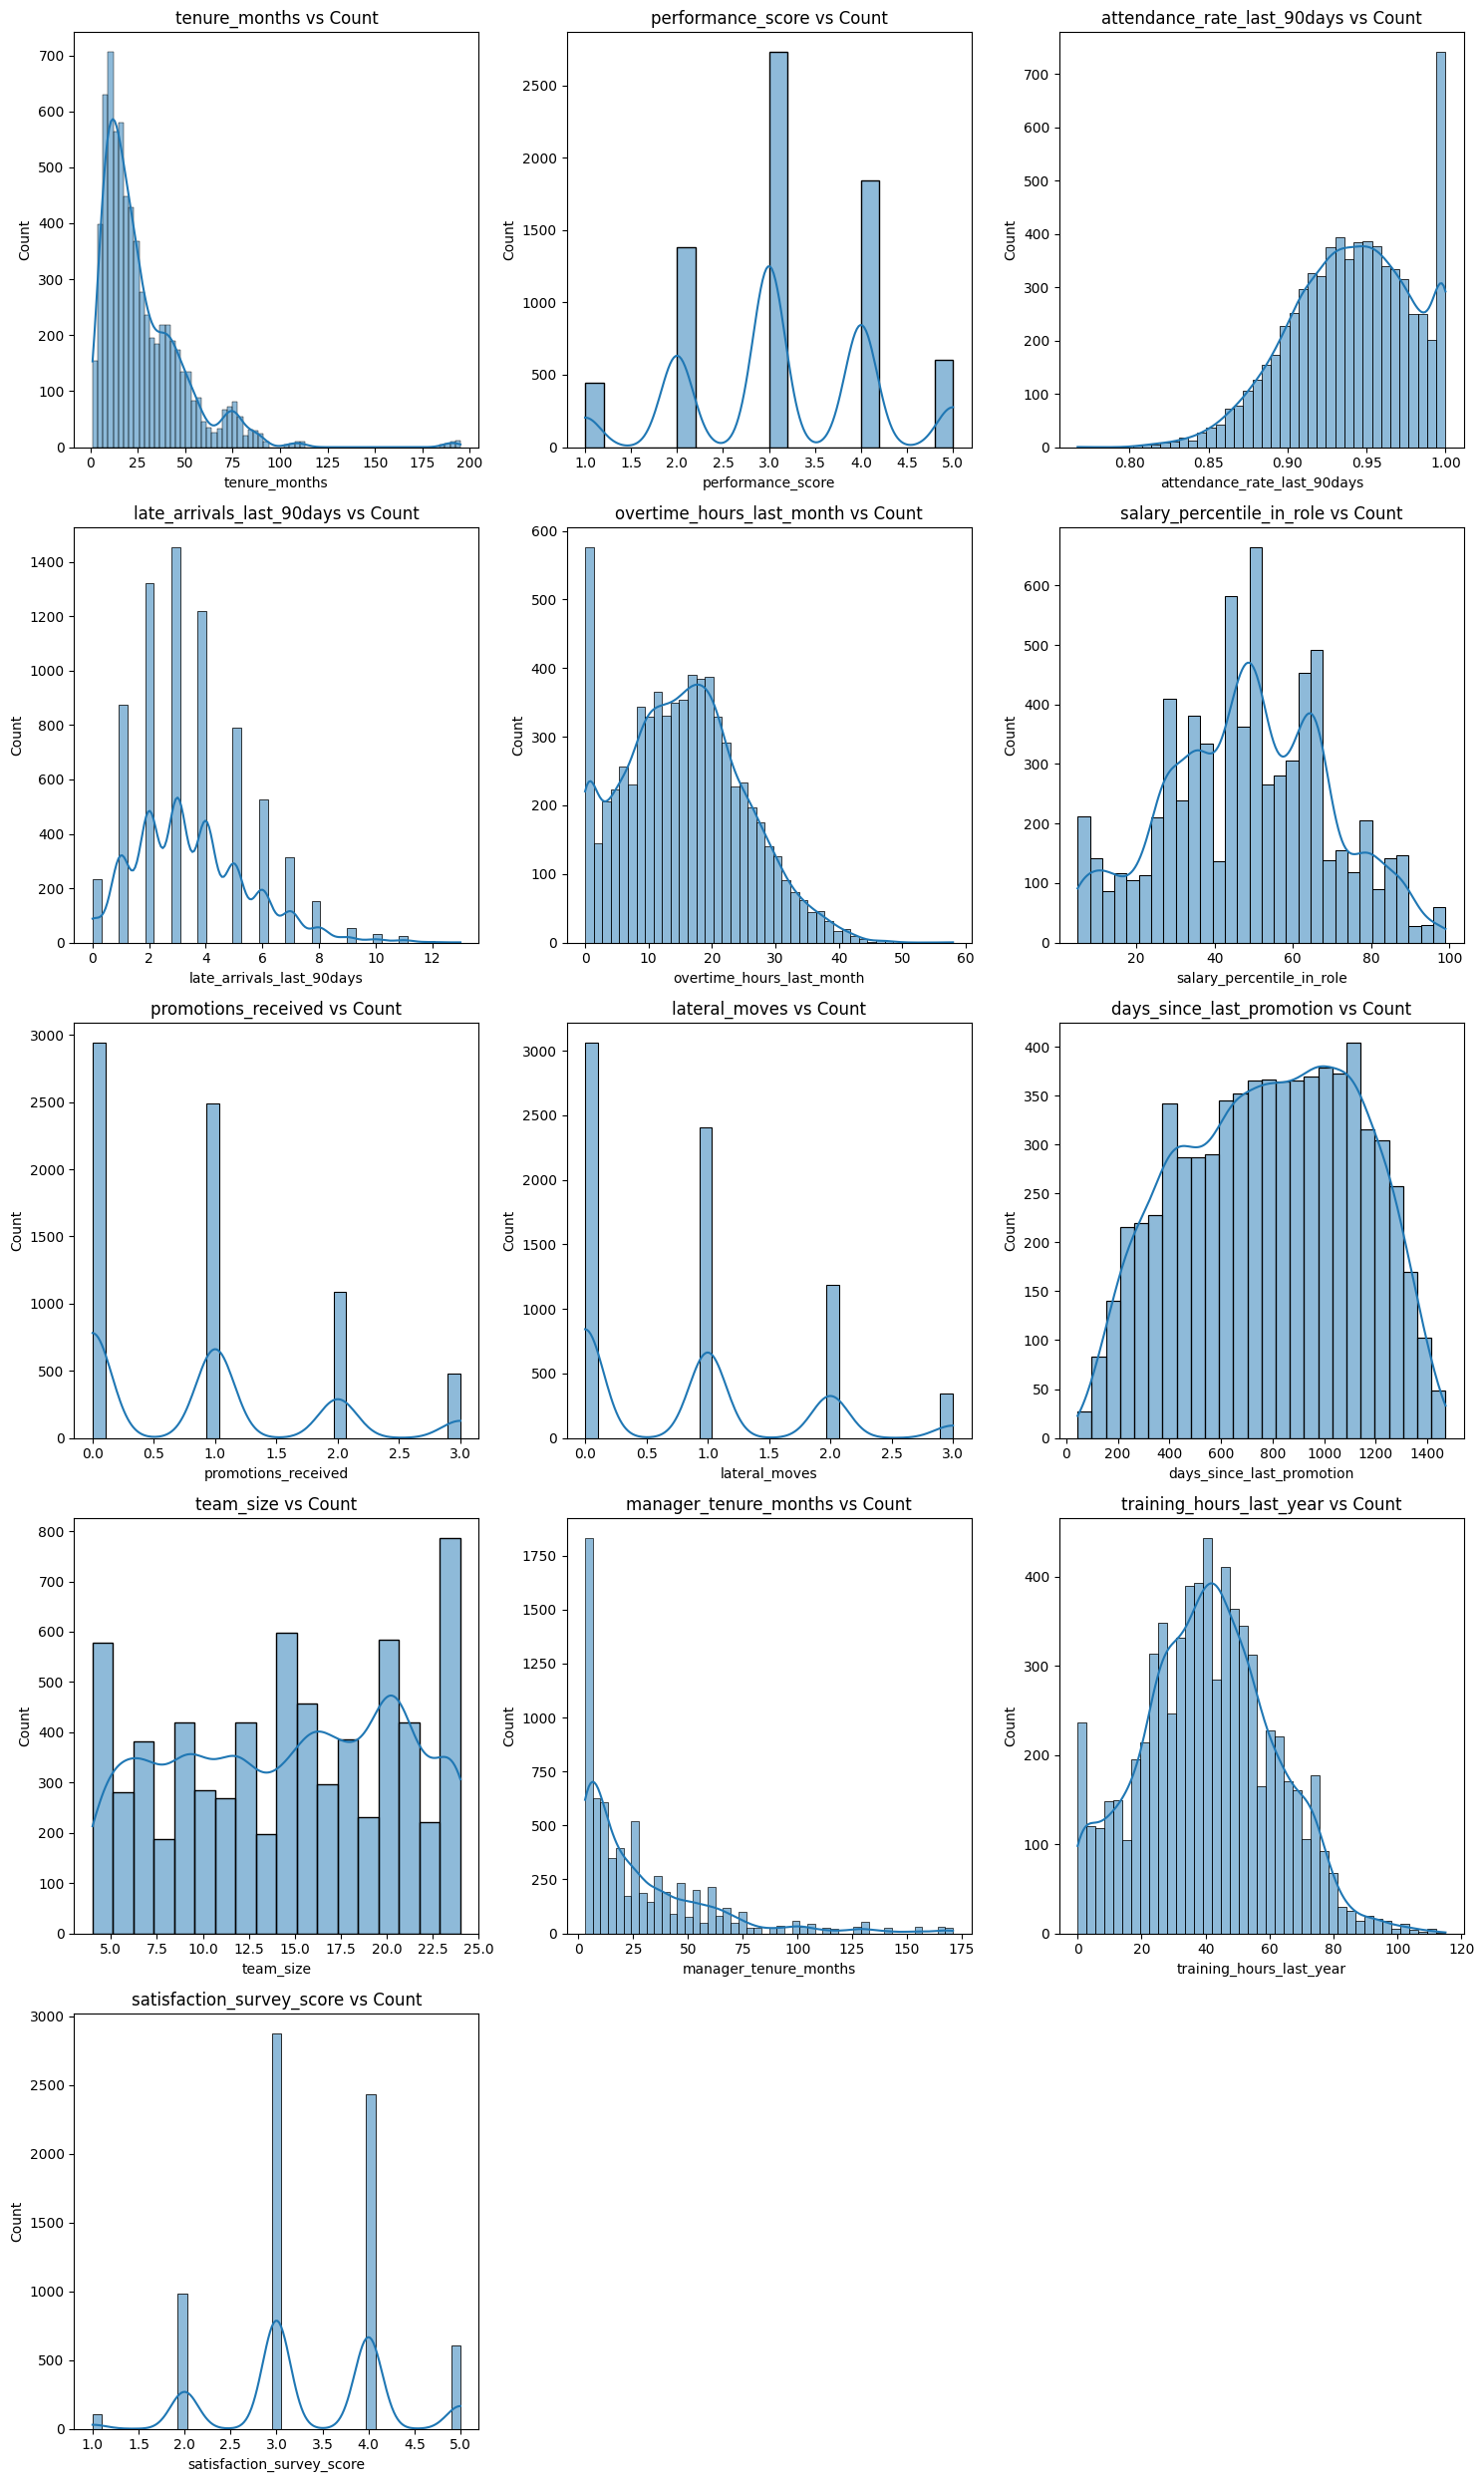

In [15]:
#distribution of numerical columns in single page

n = len(num_cols)
cols = 3  
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(train[col], kde=True)
    plt.title(f"{col} vs Count")

plt.tight_layout()
plt.show()

* **tenure_months:** Employees are spread across different tenure ranges, with more employees in lower to mid tenure.
* **performance_score:** Employees are grouped into a few common performance levels.
* **attendance_rate_last_90days:** Most employees have high attendance, very few have low attendance.
* **late_arrivals_last_90days:** Majority have very few late arrivals, only few employees have high late counts.
* **overtime_hours_last_month:** Most employees have low to moderate overtime, few have very high overtime.
* **salary_percentile_in_role:** Employees are distributed across different salary levels within their role.
* **promotions_received:** Most employees have not received promotions, very few have multiple promotions.
* **lateral_moves:** Majority have 0 or 1 lateral move, very few have higher moves.
* **days_since_last_promotion:** Many employees have long gaps since last promotion.
* **team_size:** Employees are spread across different team sizes, with more in mid-sized teams.
* **manager_tenure_months:** Most employees have relatively low manager tenure.
* **training_hours_last_year:** Most employees completed moderate training hours.
* **satisfaction_survey_score:** Most employees have medium satisfaction scores (around 3–4).


5.2 UNIVARIATE ANALYSIS for categorical column


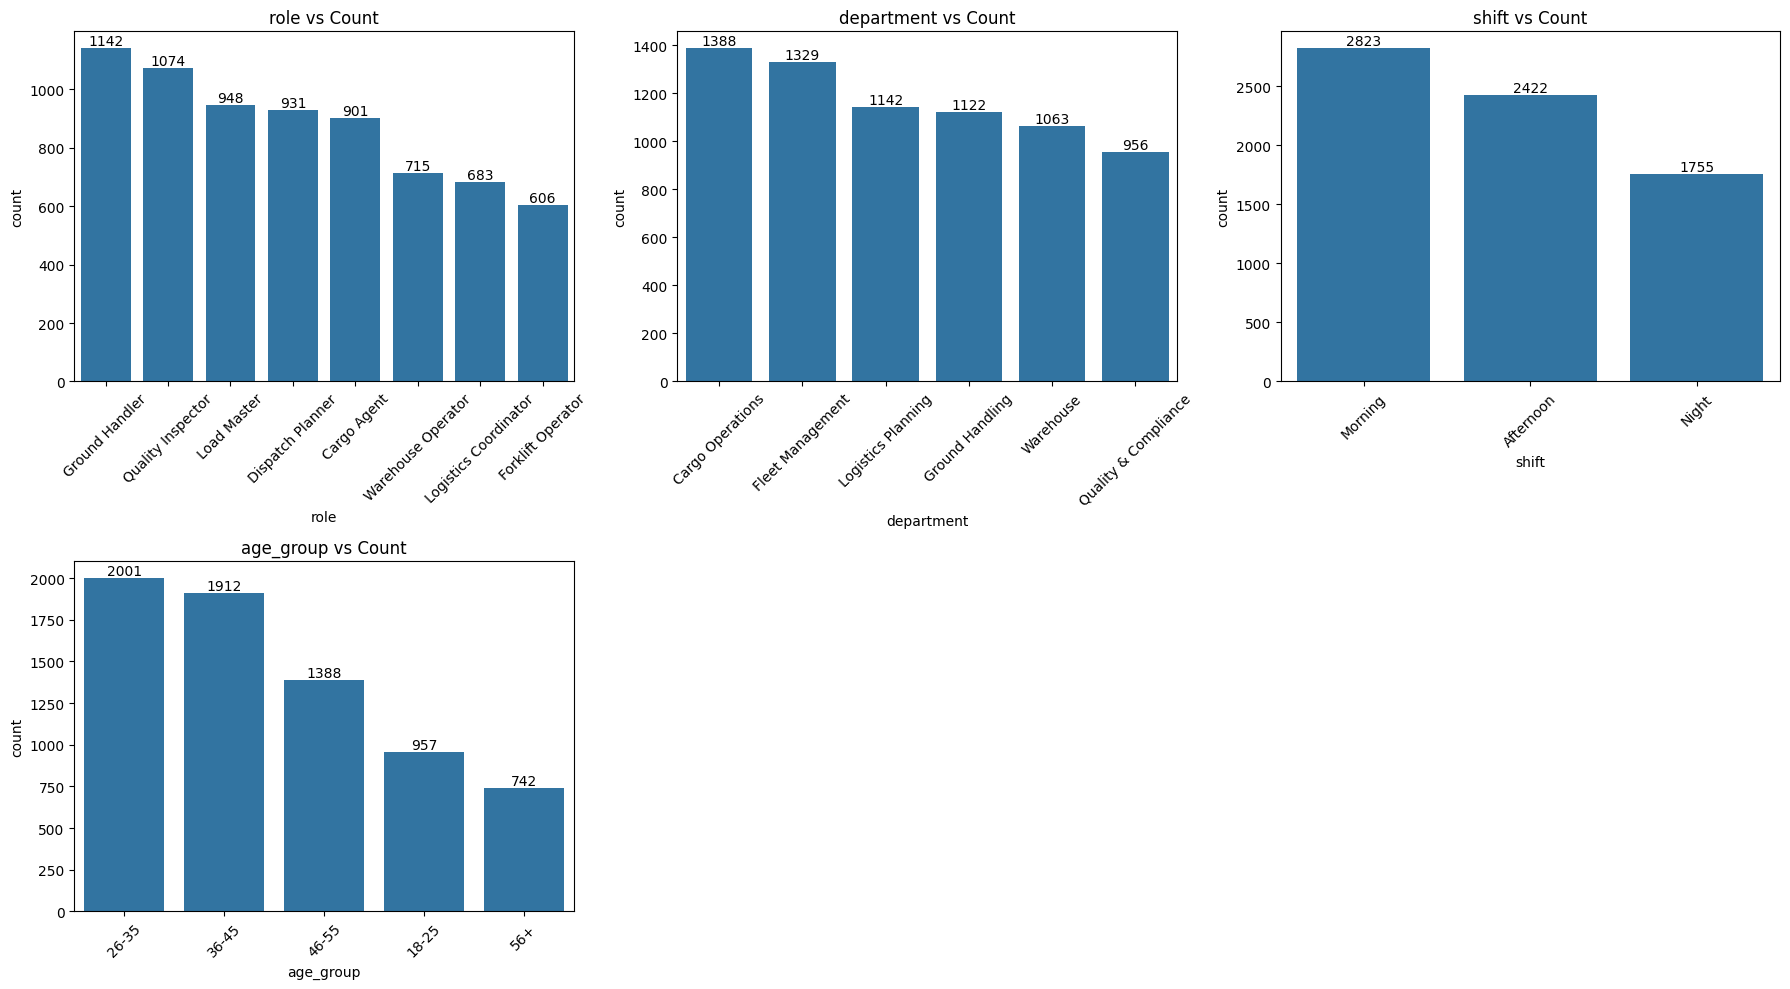

In [16]:
#distribution of categorical columns in single page
n = len(cat_cols)
cols = 3   
rows = math.ceil(n / cols)

plt.figure(figsize=(18, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)

    ax = sns.countplot(data=train, x=col, order=train[col].value_counts().index)

    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}', 
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=10
        )

    plt.title(f"{col} vs Count")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Role:** Ground Handler has the highest employee count, while Forklift Operator has the lowest.

**Department:** Cargo Operations has the highest number of employees, whereas Quality & Compliance has the least.

**Shift:** Morning shift has the highest workforce, followed by Afternoon, and Night shift has the lowest.

**Age Group:** Employees aged 26–35 are the highest in number, while the 56+ group is the smallest.

5.3 Bivariate Analysis for numerical columns

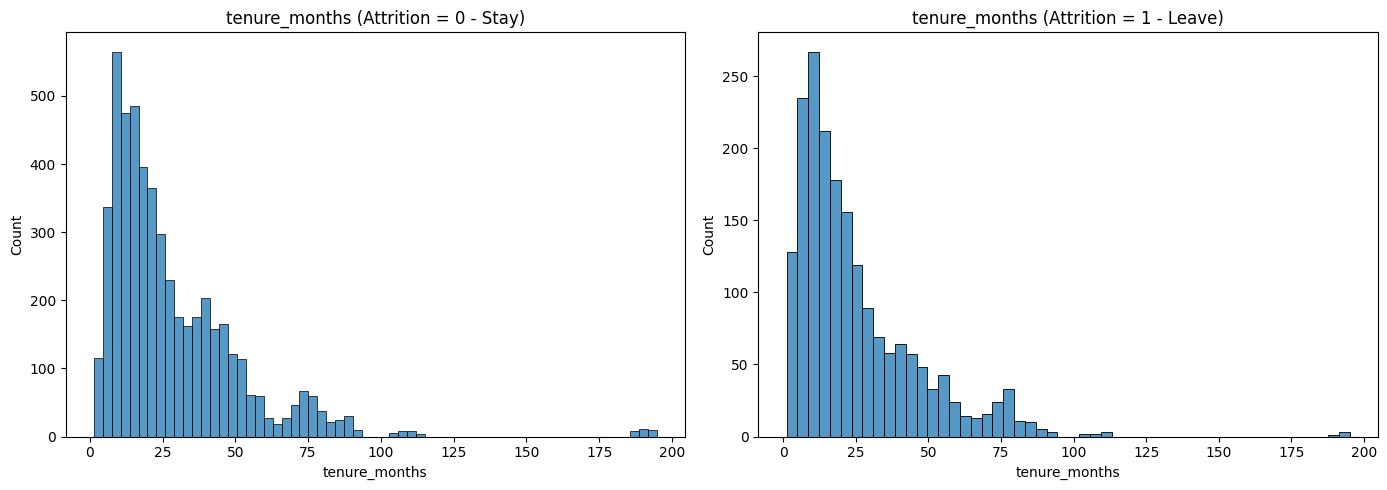

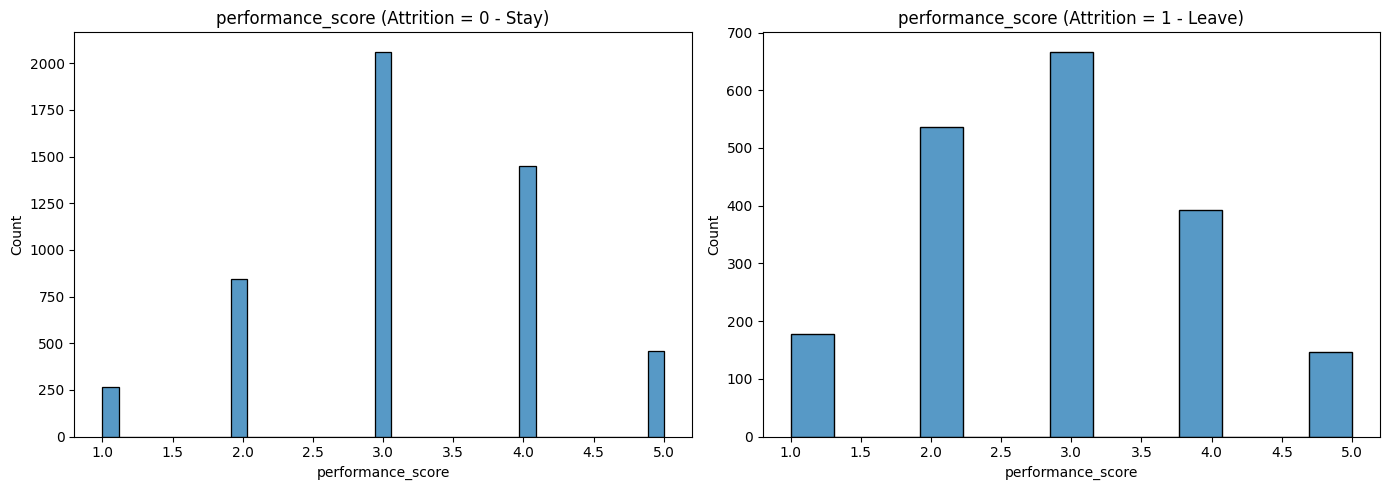

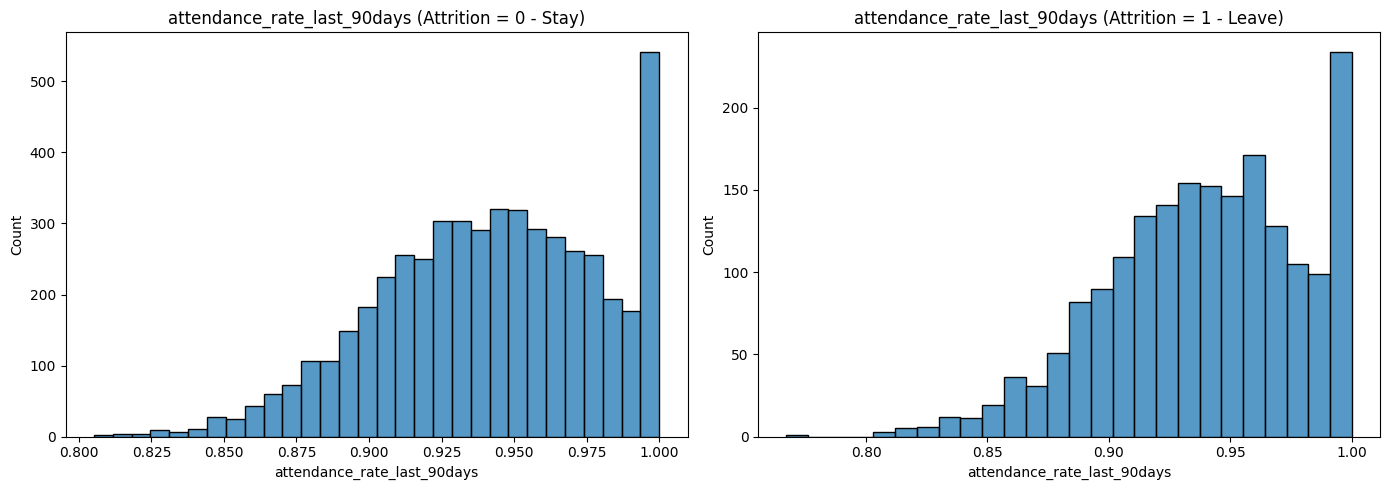

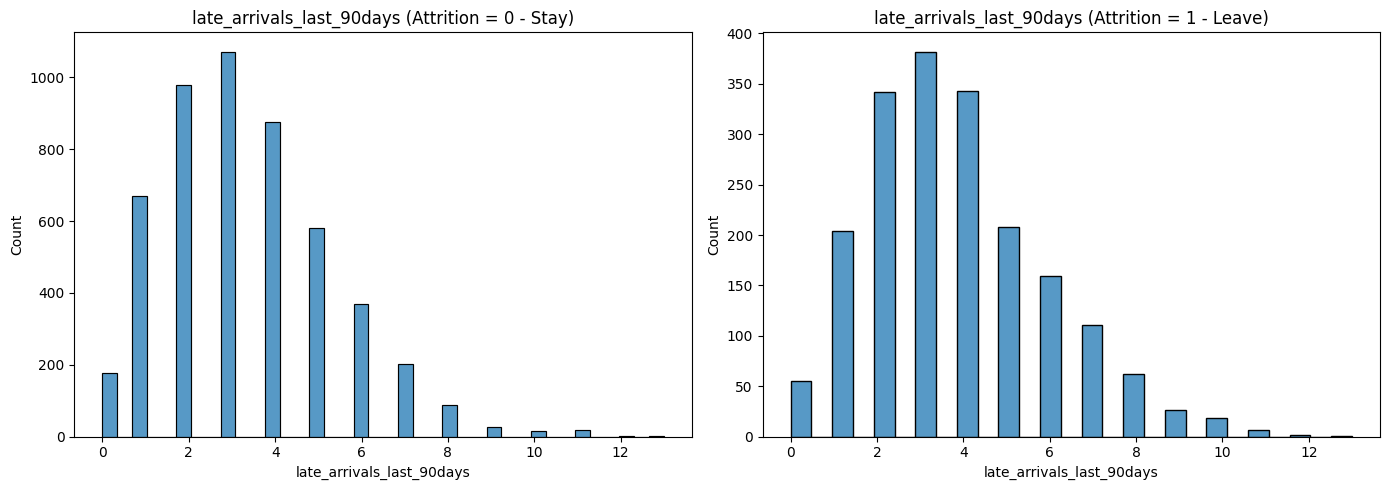

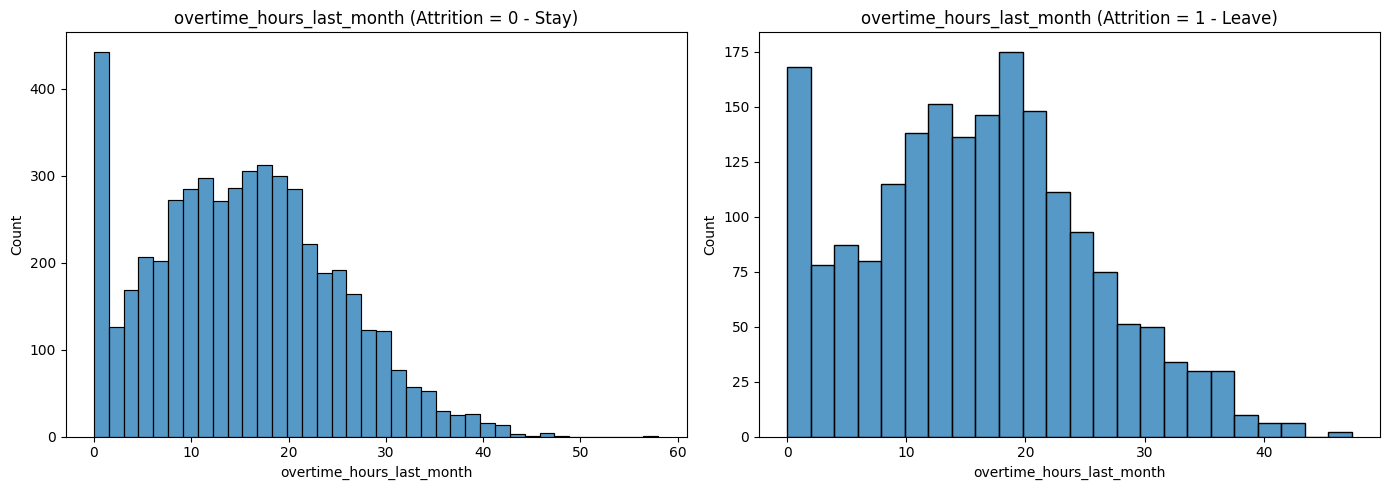

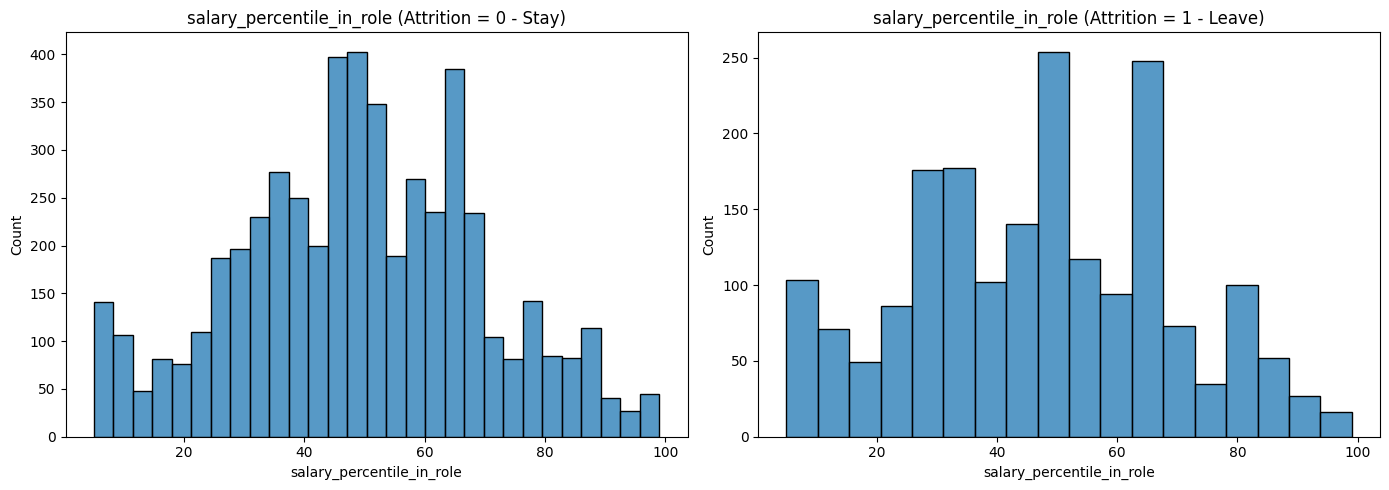

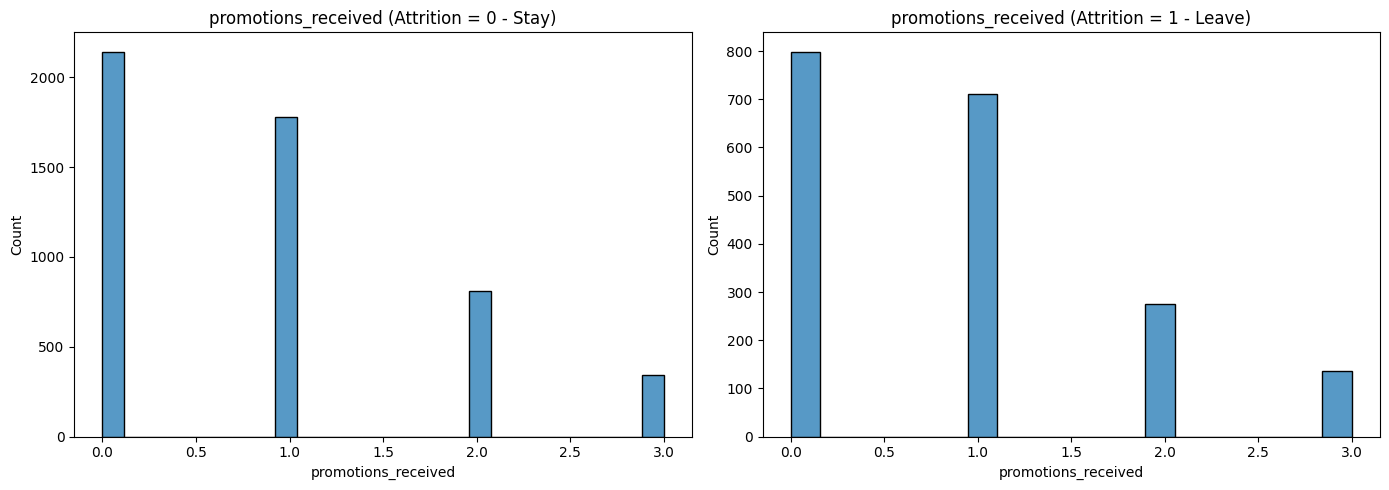

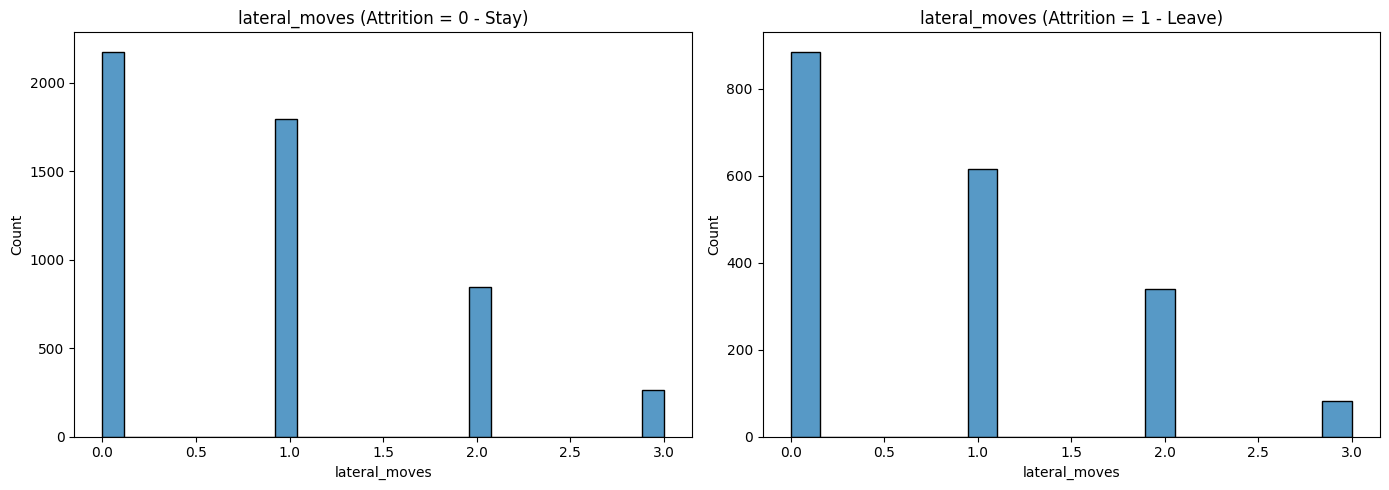

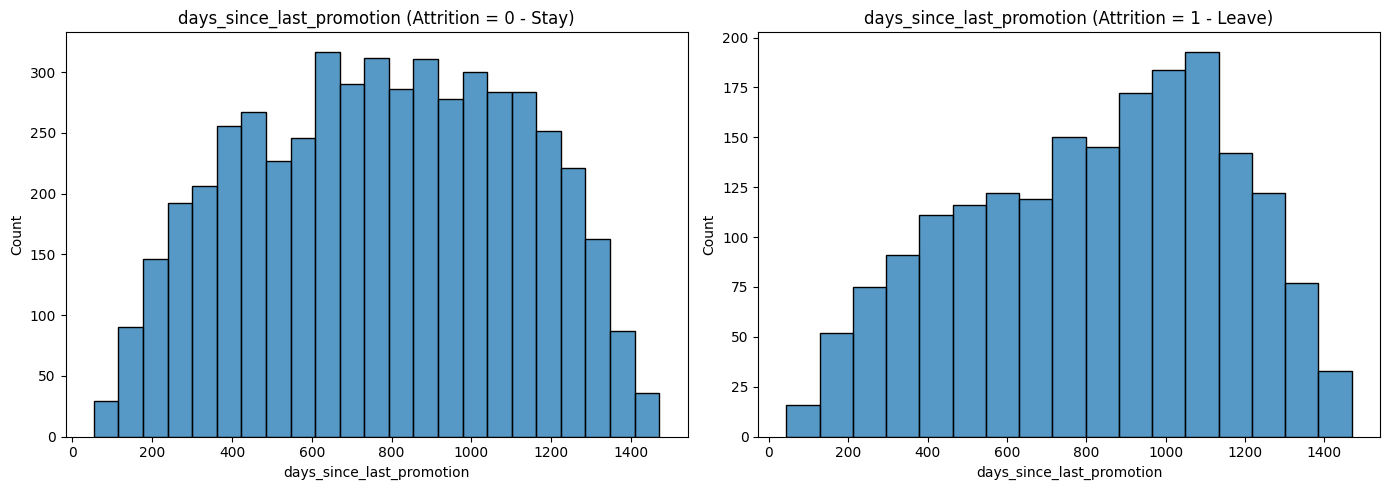

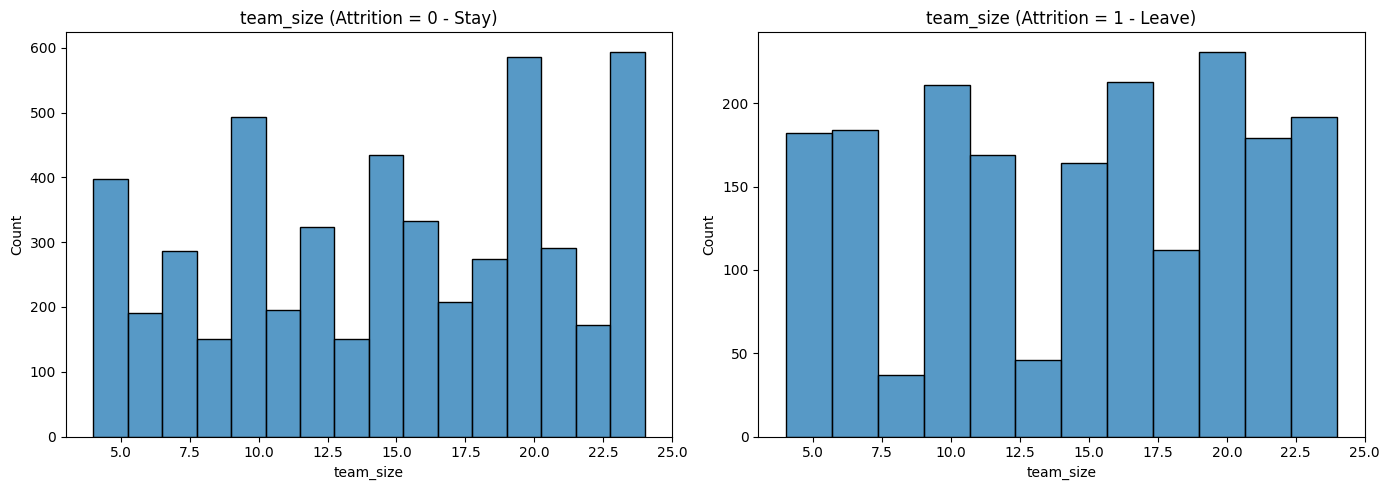

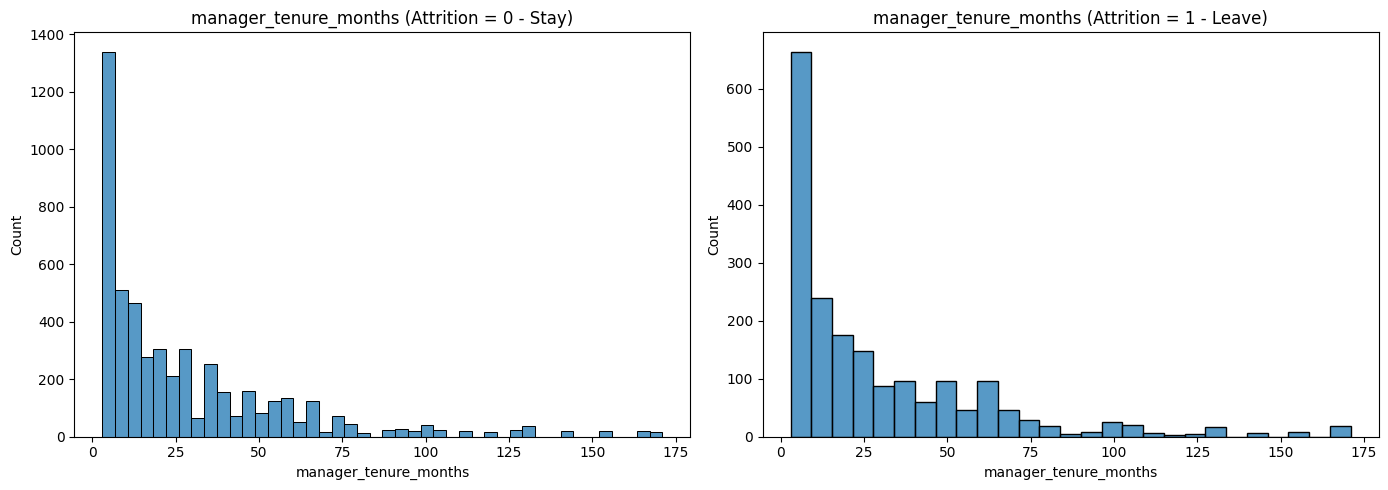

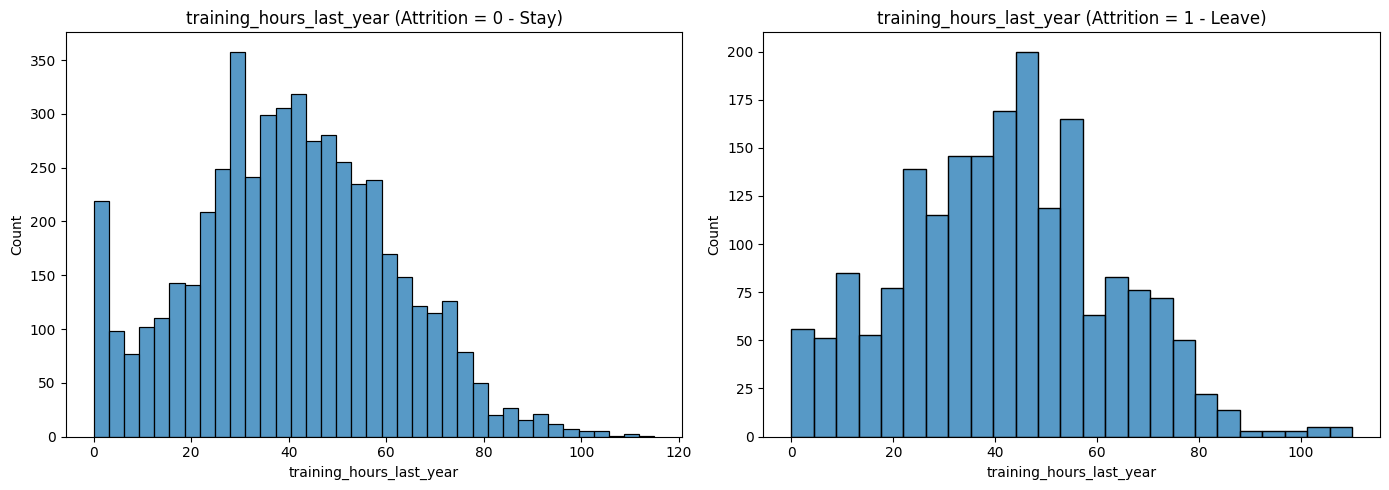

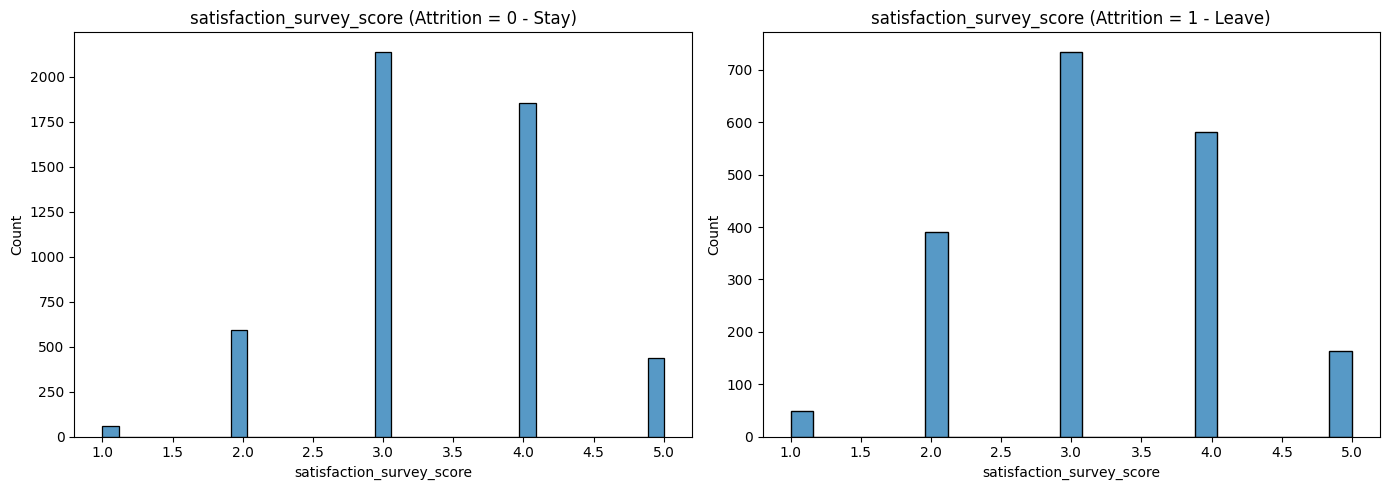

In [17]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # Attrition = 0 (Stay)
    sns.histplot(
        train[train['attrition_flag'] == 0][col],
        ax=axes[0]
    )
    axes[0].set_title(f"{col} (Attrition = 0 - Stay)")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    # Attrition = 1 (Leave)
    sns.histplot(
        train[train['attrition_flag'] == 1][col],
        ax=axes[1]
    )
    axes[1].set_title(f"{col} (Attrition = 1 - Leave)")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

**tenure_months:** Employees with lower tenure show higher attrition compared to long-tenure employees.

**performance_score:** Attrition is slightly higher among lower performance groups compared to higher performers.

**attendance_rate_last_90days:** Employees with lower attendance tend to have higher attrition.

**late_arrivals_last_90days:** Higher late arrivals are associated with increased attrition.

**overtime_hours_last_month:** Employees with higher overtime show slightly higher attrition.

**salary_percentile_in_role:** Lower salary percentile employees have higher attrition risk.

**promotions_received:** Employees with no promotions show higher attrition compared to those promoted.

**lateral_moves:** Employees with no lateral moves show higher attrition, indicating lack of internal mobility.

**days_since_last_promotion:** Longer gap since last promotion is associated with higher attrition.

**team_size:** Attrition is slightly higher in larger teams compared to smaller teams.

**manager_tenure_months:** Lower manager tenure is associated with higher employee attrition.

**training_hours_last_year:** Employees with lower training hours tend to leave more.

**satisfaction_survey_score:** Lower satisfaction scores strongly correlate with higher attrition.

5.4 Bivariate Analysis for categorical columns

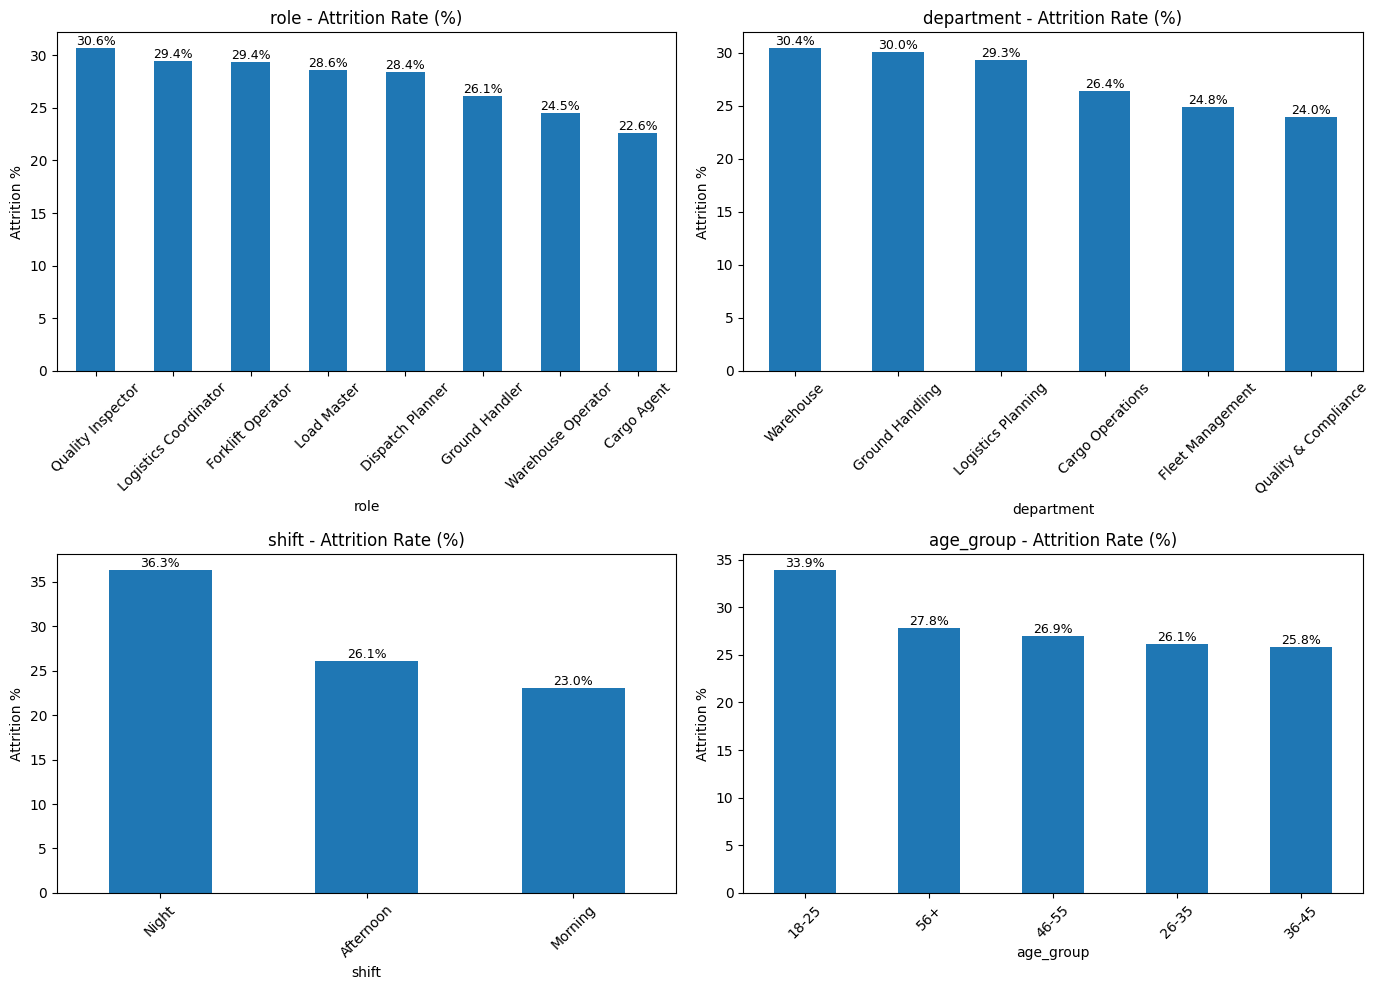

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import math

n = len(cat_cols)
cols = 2
rows = math.ceil(n / cols)

plt.figure(figsize=(14, 5 * rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(rows, cols, i)

    # Calculate attrition rate (%)
    attrition_rate = (
        train.groupby(col)['attrition_flag']
        .mean() * 100
    ).sort_values(ascending=False)

    ax = attrition_rate.plot(kind='bar')
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.title(f"{col} - Attrition Rate (%)")
    plt.ylabel("Attrition %")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**WHY PERCENTAGE INSTEAD OF COUNT**
I used percentage instead of count because categorical groups have different number of employees, and counts can be misleading.
Percentage (attrition rate) normalizes the data by considering the total employees in each category.
This helps in identifying the true risk of attrition within each group rather than just volume.

**Role:** Quality Inspector, Cargo Agent, and Logistics Coordinator show the highest attrition rates, while Ground Handler has the lowest attrition rate.

**Department:** Logistics Planning and Warehouse have higher attrition rates, whereas Cargo Operations and Quality & Compliance have lower attrition.

**Shift:** Night shift has the highest attrition rate, followed by Afternoon, while Morning shift has the lowest attrition.

**Age Group:** Employees aged 36–45 and 46–55 show higher attrition, while younger (26–35) and older (56+) groups have lower attrition.

5.5 Handling skewed data


In [19]:
train.skew(numeric_only=True)

tenure_months                  2.473026
performance_score             -0.098000
attendance_rate_last_90days   -0.383344
late_arrivals_last_90days      0.747900
overtime_hours_last_month      0.294450
salary_percentile_in_role     -0.013181
promotions_received            0.795646
lateral_moves                  0.771354
days_since_last_promotion     -0.121763
team_size                     -0.108885
manager_tenure_months          1.956273
training_hours_last_year       0.139483
satisfaction_survey_score     -0.111995
attrition_flag                 1.012040
dtype: float64

In [20]:
val.skew(numeric_only=True)
test.skew(numeric_only=True)

tenure_months                  2.169449
performance_score             -0.105444
attendance_rate_last_90days   -0.371659
late_arrivals_last_90days      0.977781
overtime_hours_last_month      0.322352
salary_percentile_in_role     -0.036980
promotions_received            0.776608
lateral_moves                  0.729747
days_since_last_promotion     -0.151845
team_size                     -0.094634
manager_tenure_months          1.839934
training_hours_last_year       0.110067
satisfaction_survey_score     -0.032806
attrition_flag                 1.083584
dtype: float64

In [21]:
import numpy as np

skew_cols = [
    'tenure_months',
    'manager_tenure_months',
]

for col in skew_cols:
    train[col] = np.log1p(train[col])
    val[col] = np.log1p(val[col])   
    test[col] = np.log1p(test[col]) 

In [22]:
val[skew_cols].skew()

tenure_months            0.443285
manager_tenure_months    0.060709
dtype: float64

In [23]:
train[skew_cols].skew()

tenure_months           -0.019237
manager_tenure_months    0.074230
dtype: float64

**6.Feature Splitting and Encoding**

**6.1 Feature Splitting**

In [24]:
# Train
X_train = train.drop('attrition_flag', axis=1)
y_train = train['attrition_flag']

# Validation
X_val = val.drop('attrition_flag', axis=1)
y_val = val['attrition_flag']

# Test
X_test = test.drop('attrition_flag', axis=1)
y_test = test['attrition_flag']

In [25]:
drop_cols = ['employee_id', 'observation_date','team_size']

X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_val = X_val.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

**6.2 Data Store for CATboost**


In [26]:
# Save raw copies for CatBoost

X_train_cat = X_train.copy()
X_val_cat   = X_val.copy()
X_test_cat  = X_test.copy()

In [27]:
import joblib

joblib.dump(X_train_cat,'X_train_cat.pkl')
joblib.dump(X_val_cat,'X_val_cat.pkl')
joblib.dump(X_test_cat,'X_test_cat.pkl')

['X_test_cat.pkl']

6.2 **Encoding the categorical data**

In [28]:
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val   = pd.get_dummies(X_val, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

In [29]:
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [30]:
X_train

,tenure_months,performance_score,attendance_rate_last_90days,late_arrivals_last_90days,overtime_hours_last_month,salary_percentile_in_role,promotions_received,lateral_moves,days_since_last_promotion,manager_tenure_months,...,department_Ground Handling,department_Logistics Planning,department_Quality & Compliance,department_Warehouse,shift_Morning,shift_Night,age_group_26-35,age_group_36-45,age_group_46-55,age_group_56+
0,3.173878,3,0.9345,3,19.7,81.6,0,2,835,4.663439,...,False,True,False,False,False,True,False,True,False,False
1,3.261935,3,0.9618,4,0.0,84.1,2,0,176,3.637586,...,False,False,False,False,True,False,False,True,False,False
2,3.010621,3,0.9338,3,14.4,37.5,0,0,268,3.401197,...,False,False,True,False,True,False,False,True,False,False
3,2.766319,1,1.0000,3,24.5,5.0,0,1,583,3.401197,...,True,False,False,False,False,False,False,True,False,False
4,4.329417,3,0.9697,8,23.1,27.6,0,1,394,3.332205,...,True,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,3.808882,5,0.9078,5,24.5,64.1,0,0,843,2.639057,...,True,False,False,False,False,False,False,False,False,True
6996,4.234107,5,1.0000,4,19.0,52.7,2,1,1179,2.302585,...,False,True,False,False,False,False,False,True,False,False
6997,3.091042,3,0.8963,2,26.6,28.2,1,3,982,4.094345,...,False,False,False,False,False,False,True,False,False,False
6998,4.342506,3,0.9370,5,11.2,28.1,2,0,1105,2.890372,...,False,False,False,True,True,False,False,False,True,False


**6.3 Standard Scaler**

In [31]:
from sklearn.preprocessing import StandardScaler
import joblib

# Refit scaler on FINAL training features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

# overwrite old scaler file
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("New scaler saved successfully")

New scaler saved successfully


**7. Save the data for model building**

In [32]:
import joblib

joblib.dump(X_train, "X_train.pkl")
joblib.dump(y_train, "y_train.pkl")

joblib.dump(X_val, "X_val.pkl")
joblib.dump(y_val, "y_val.pkl")

joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**8.Final Checkups**

In [33]:
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0
0


In [34]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(7000, 30)
(1500, 30)
(1500, 30)
